Dataset Shape: (20, 3)

── DATASET PREVIEW ──
    Sales  Units_Sold  Customer_Age
0     200          10            23
1     220          12            35
2     215          11            45
3     190           9            28
4     300          15            52
5     185           8            31
6     210          11            40
7     225          13            27
8     500          25            65
9     195          10            33
10    205          10            29
11    215          11            38
12    180           9            22
13    195          10            41
14    600          30            70
15    210          11            36
16    225          12            44
17    200          10            25
18    195          10            32
19    215          11            39

══════════════════════════════════════
       SUMMARY STATISTICS
══════════════════════════════════════

  [ Sales ]
  Mean    : 244.00
  Median  : 210.00
  Std Dev : 108.73
  Min     : 180
  Max  

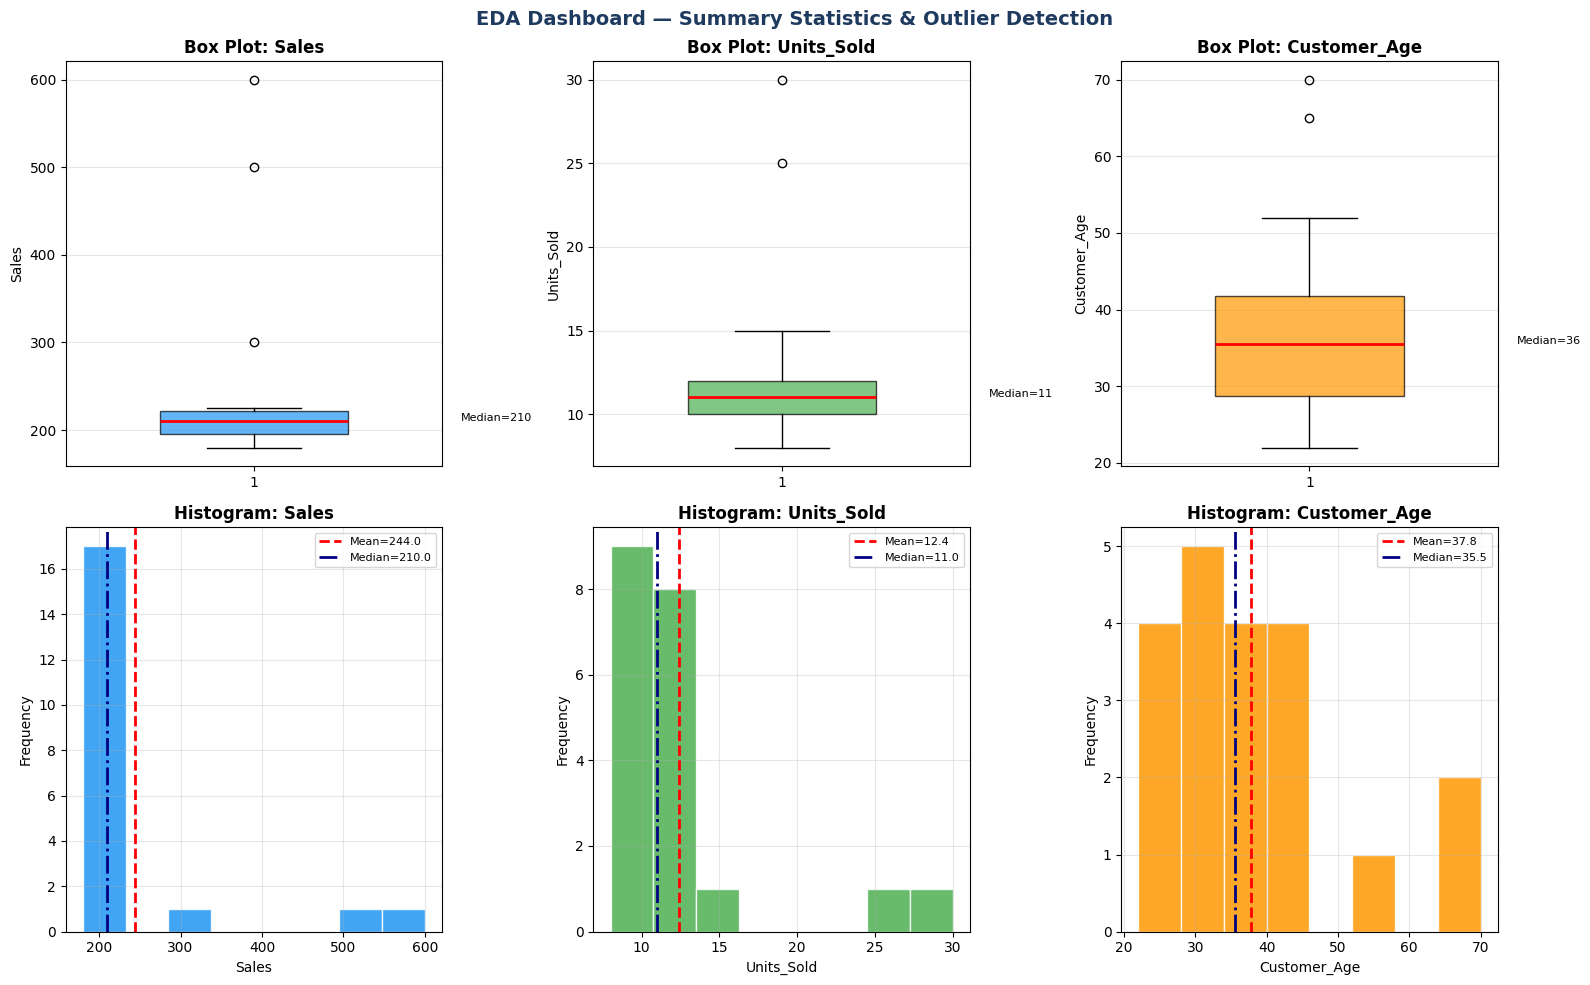


── Z-SCORE ANALYSIS ──
Sales: Z>2 outliers = [500, 600]
Units_Sold: Z>2 outliers = [25, 30]
Customer_Age: Z>2 outliers = [65, 70]

All visualizations saved as eda_visualization.png


In [1]:
# ================================================================
# EDA: Summary Statistics, Outlier Detection & Visualization
# Subject: Data Science and Analytics | Assignment 2 - Q3
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Dataset ────────────────────────────────────────────────────────
data = {
    'Sales':       [200,220,215,190,300,185,210,225,500,195,
                    205,215,180,195,600,210,225,200,195,215],
    'Units_Sold':  [10,12,11,9,15,8,11,13,25,10,
                    10,11,9,10,30,11,12,10,10,11],
    'Customer_Age':[23,35,45,28,52,31,40,27,65,33,
                    29,38,22,41,70,36,44,25,32,39],
}

df = pd.DataFrame(data)
print('Dataset Shape:', df.shape)
print('\n── DATASET PREVIEW ──')
print(df.to_string())

# ── STEP 1: Summary Statistics ─────────────────────────────────────
print('\n══════════════════════════════════════')
print('       SUMMARY STATISTICS')
print('══════════════════════════════════════')
for col in df.columns:
    print(f'\n  [ {col} ]')
    print(f'  Mean    : {df[col].mean():.2f}')
    print(f'  Median  : {df[col].median():.2f}')
    print(f'  Std Dev : {df[col].std():.2f}')
    print(f'  Min     : {df[col].min()}')
    print(f'  Max     : {df[col].max()}')
    print(f'  Skewness: {df[col].skew():.4f}')

# Full describe()
print('\n── FULL DESCRIBE ──')
print(df.describe().round(2))

# ── STEP 2: Outlier Detection using IQR ───────────────────────────
print('\n══════════════════════════════════════')
print('       OUTLIER DETECTION (IQR Method)')
print('══════════════════════════════════════')

outlier_summary = {}

for col in df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_fence) | (df[col] > upper_fence)][col]
    outlier_summary[col] = outliers.tolist()

    print(f'\n  [ {col} ]')
    print(f'  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}')
    print(f'  Lower Fence = {lower_fence:.2f}')
    print(f'  Upper Fence = {upper_fence:.2f}')
    if len(outliers) > 0:
      print(f'  OUTLIERS FOUND: {outliers.tolist()}')
    else:
      print(f'  No outliers detected.')

# ── STEP 3: Visualizations ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA Dashboard — Summary Statistics & Outlier Detection',
             fontsize=14, fontweight='bold', color='#1E3A5F')

colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, col in enumerate(df.columns):

    # --- Box Plot ---
    ax_box = axes[0, i]
    bp = ax_box.boxplot(df[col], patch_artist=True, notch=False,
                        vert=True, widths=0.5)
    bp['boxes'][0].set_facecolor(colors[i])
    bp['boxes'][0].set_alpha(0.7)
    bp['medians'][0].set_color('red')
    bp['medians'][0].set_linewidth(2)

    # Annotate Q1, Q3, Median
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    med = df[col].median()
    ax_box.annotate(f'Median={med:.0f}', xy=(1.05, med),
                    xycoords=('axes fraction', 'data'), fontsize=8)
    ax_box.set_title(f'Box Plot: {col}', fontweight='bold')
    ax_box.set_ylabel(col)
    ax_box.grid(True, alpha=0.3, axis='y')

    # --- Histogram ---
    ax_hist = axes[1, i]
    n, bins, patches = ax_hist.hist(df[col], bins=8, color=colors[i],
                                     edgecolor='white', alpha=0.85)

    # Add mean and median lines
    ax_hist.axvline(df[col].mean(), color='red', linestyle='--',
                    linewidth=2, label=f'Mean={df[col].mean():.1f}')
    ax_hist.axvline(df[col].median(), color='navy', linestyle='-.',
                    linewidth=2, label=f'Median={df[col].median():.1f}')
    ax_hist.set_title(f'Histogram: {col}', fontweight='bold')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Frequency')
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# ── STEP 4: Z-Score based outlier check ───────────────────────────
print('\n── Z-SCORE ANALYSIS ──')
for col in df.columns:
    z_scores = np.abs(stats.zscore(df[col]))
    z_outliers = df[col][z_scores > 2].tolist()
    print(f'{col}: Z>2 outliers = {z_outliers}')

print('\nAll visualizations saved as eda_visualization.png')


In [2]:
# ================================================================
# Complete Data Profiling: Missing Values, Duplicates, Outliers
# Subject: Data Science and Analytics | Assignment 2 - Q5
# ================================================================

import pandas as pd
import numpy as np
from scipy import stats

# Create sample dataset with quality issues
data = {
    'CustomerID': [1,2,3,4,5,5,6,7,8,9,10,None,12,13,14,15,16,17,18,19],
    'Age':   [25,None,45,60,33,33,None,29,55,41,38,None,67,50,44,31,58,27,None,900],
    'Salary':[30000,45000,None,80000,52000,52000,67000,None,90000,71000,
              58000,83000,None,77000,62000,48000,None,35000,92000,1000000],
    'City':  ['Pune','Mumbai','Delhi','Pune',None,'Pune','Nagpur','Mumbai',
              'Delhi',None,'Pune','Mumbai','Delhi','Pune','Nagpur',
              'Mumbai','Delhi','Pune',None,'Mumbai'],
}
df = pd.DataFrame(data)

print('=== DATA PROFILING REPORT ===')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Dtypes:\n{df.dtypes}')

# ── 1. Missing Values ───────────────────────────────────────────
print('\n--- MISSING VALUES ---')
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
print(pd.DataFrame({'Count': missing, 'Percent %': missing_pct}))

# ── 2. Duplicates ───────────────────────────────────────────────
print('\n--- DUPLICATES ---')
total_dups = df.duplicated().sum()
print(f'Full duplicate rows: {total_dups}')
key_dups = df.duplicated(subset=['CustomerID']).sum()
print(f'CustomerID duplicates: {key_dups}')
if total_dups > 0:
    print('Duplicate rows:')
    print(df[df.duplicated(keep=False)])

# ── 3. Outliers (Numeric columns only) ─────────────────────────
print('\n--- OUTLIER DETECTION (IQR + Z-Score) ---')
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    clean = df[col].dropna()
    Q1, Q3 = clean.quantile(0.25), clean.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1-1.5*IQR, Q3+1.5*IQR
    iqr_out = clean[(clean < lower) | (clean > upper)]
    z_out   = clean[np.abs(stats.zscore(clean)) > 3]
    print(f'\n  {col}:')
    print(f'    IQR  Outliers: {iqr_out.tolist()}')
    print(f'    Z>3  Outliers: {z_out.tolist()}')

print('\n=== END OF PROFILING REPORT ===')


=== DATA PROFILING REPORT ===
Shape: (20, 4)
Columns: ['CustomerID', 'Age', 'Salary', 'City']
Dtypes:
CustomerID    float64
Age           float64
Salary        float64
City           object
dtype: object

--- MISSING VALUES ---
            Count  Percent %
CustomerID      1        5.0
Age             4       20.0
Salary          4       20.0
City            3       15.0

--- DUPLICATES ---
Full duplicate rows: 0
CustomerID duplicates: 1

--- OUTLIER DETECTION (IQR + Z-Score) ---

  CustomerID:
    IQR  Outliers: []
    Z>3  Outliers: []

  Age:
    IQR  Outliers: [900.0]
    Z>3  Outliers: [900.0]

  Salary:
    IQR  Outliers: [1000000.0]
    Z>3  Outliers: [1000000.0]

=== END OF PROFILING REPORT ===
